# 01 Data Exploration & Visual Profiling

In [6]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


## 2. Load Dataset

In [7]:
DATA_DIR = '../dataset'
TRAIN_PATH = os.path.join(DATA_DIR, 'train.csv')
TEST_PATH = os.path.join(DATA_DIR, 'test.csv')
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, 'sample_submission.csv')

print(f"Loading train set from: {TRAIN_PATH}")
train_df = pd.read_csv(TRAIN_PATH)
print(f"Train shape: {train_df.shape}")

print(f"Loading test set from: {TEST_PATH}")
test_df = pd.read_csv(TEST_PATH)
print(f"Test shape: {test_df.shape}")

print(f"Loading sample submission from: {SAMPLE_SUB_PATH}")
sample_sub_df = pd.read_csv(SAMPLE_SUB_PATH)
print(f"Sample sub shape: {sample_sub_df.shape}")


Loading train set from: ../dataset\train.csv
Train shape: (2249698, 6)
Loading test set from: ../dataset\test.csv
Test shape: (734736, 5)
Loading sample submission from: ../dataset\sample_submission.csv
Sample sub shape: (734736, 2)


## 3. Dataset Overview

In [8]:
print("=== Train Dataset Overview ===")
print(f"Number of rows: {len(train_df):,}")
print(f"Number of columns: {len(train_df.columns)}")
print(f"Column names: {list(train_df.columns)}")
print("\nData Types:")
print(train_df.dtypes)
print("\nMemory Usage:")
print(f"{train_df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
display(train_df.head(3))


=== Train Dataset Overview ===
Number of rows: 2,249,698
Number of columns: 6
Column names: ['PRODUCT_ID', 'TITLE', 'BULLET_POINTS', 'DESCRIPTION', 'PRODUCT_TYPE_ID', 'PRODUCT_LENGTH']

Data Types:
PRODUCT_ID           int64
TITLE                  str
BULLET_POINTS          str
DESCRIPTION            str
PRODUCT_TYPE_ID      int64
PRODUCT_LENGTH     float64
dtype: object

Memory Usage:
1703.82 MB


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
0,1925202,"ArtzFolio Tulip Flowers Blackout Curtain for Door, Window & Room | Eyelets & Tie Back | Canvas Fabric | Width 4.5feet (54inch) Height 5 feet (60 inch); Set of 2 PCS","[LUXURIOUS & APPEALING: Beautiful custom-made curtains to decorate any home or office | Includes inbuilt tieback to hold the curtain | Completely finished and ready to hang on walls & windows,MATE...",NaN,1650,2125.9800
1,2673191,Marks & Spencer Girls' Pyjama Sets T86_2561C_Navy Mix_9-10Y,"[Harry Potter Hedwig Pyjamas (6-16 Yrs),100% cotton (exclusive of trimmings),Ribbing - 98% cotton, 2% elastane]",NaN,2755,393.7000
2,2765088,PRIKNIK Horn Red Electric Air Horn Compressor Interior Dual Tone Trumpet Loud Compatible with SX4,"[Loud Dual Tone Trumpet Horn, Compatible With SX4,Electric Air Horn with Compressor, Compatible With SX4,High Quality, High Intensity Horn Sound, Compatible With SX4,Color: Red, Compatible With SX...","Specifications: Color: Red, Material: Aluminium, Voltage: 12V, dB: 130 dB (around), Material: Aluminum Pump Head + Steel Pump Body + ABS Shell and Parts DB output: 130db Voltage: 12v Sound Type: D...",7537,748.0315


## 4. Missing & Empty Values Analysis

,Column,Null Count,Empty Strings,Total Missing,Missing Pct (%)
0,PRODUCT_ID,0,0,0,0.0000
1,TITLE,13,0,13,0.0006
2,BULLET_POINTS,837366,0,837366,37.2213
3,DESCRIPTION,1157382,0,1157382,51.4461
4,PRODUCT_TYPE_ID,0,0,0,0.0000
5,PRODUCT_LENGTH,0,0,0,0.0000


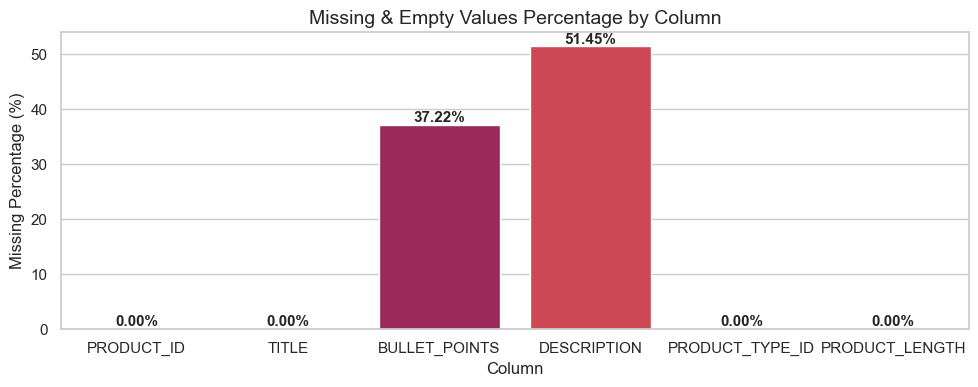

In [9]:
text_cols = ['TITLE', 'DESCRIPTION', 'BULLET_POINTS']

missing_summary = []
for col in train_df.columns:
    null_cnt = train_df[col].isnull().sum()
    empty_cnt = (train_df[col].astype(str).str.strip() == '').sum()
    total_missing = null_cnt + empty_cnt
    missing_pct = (total_missing / len(train_df)) * 100
    missing_summary.append({
        'Column': col,
        'Null Count': null_cnt,
        'Empty Strings': empty_cnt,
        'Total Missing': total_missing,
        'Missing Pct (%)': missing_pct
    })

missing_df = pd.DataFrame(missing_summary)
display(missing_df)

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=missing_df, x='Column', y='Missing Pct (%)', palette='rocket')
plt.title('Missing & Empty Values Percentage by Column')
plt.ylabel('Missing Percentage (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Duplicate Analysis

In [10]:
print("=== Duplicate Analysis ===")
exact_dupes = train_df.duplicated().sum()
print(f"Exact Duplicate Rows: {exact_dupes:,}")

pid_dupes = train_df['PRODUCT_ID'].duplicated().sum()
print(f"Duplicate PRODUCT_IDs: {pid_dupes:,}")

title_dupes = train_df['TITLE'].duplicated().sum()
print(f"Duplicate TITLEs: {title_dupes:,} ({(title_dupes/len(train_df))*100:.2f}%)")

if title_dupes > 0:
    dupe_titles = train_df[train_df['TITLE'].duplicated(keep=False)].sort_values('TITLE')
    display(dupe_titles[['PRODUCT_ID', 'TITLE', 'PRODUCT_LENGTH']].head(4))


=== Duplicate Analysis ===
Exact Duplicate Rows: 0
Duplicate PRODUCT_IDs: 0
Duplicate TITLEs: 38,936 (1.73%)


,PRODUCT_ID,TITLE,PRODUCT_LENGTH
13249,1663221,"""Laptop Backpack|| Laptop Bag||College Bag||Backpack||Office Bag||Casual Bag||Urban Backpack||Day Backpack||Evening Backpack||School Bag""",2400.0000
365451,1640974,"""Laptop Backpack|| Laptop Bag||College Bag||Backpack||Office Bag||Casual Bag||Urban Backpack||Day Backpack||Evening Backpack||School Bag""",2400.0000
619150,1629943,"""Laptop Backpack|| Laptop Bag||College Bag||Backpack||Office Bag||Casual Bag||Urban Backpack||Day Backpack||Evening Backpack||School Bag""",2400.0000
993180,1624419,"""Laptop Backpack|| Laptop Bag||College Bag||Backpack||Office Bag||Casual Bag||Urban Backpack||Day Backpack||Evening Backpack||School Bag""",2400.0000


## 6. Product Type Analysis

Number of unique PRODUCT_TYPE_IDs: 12,907


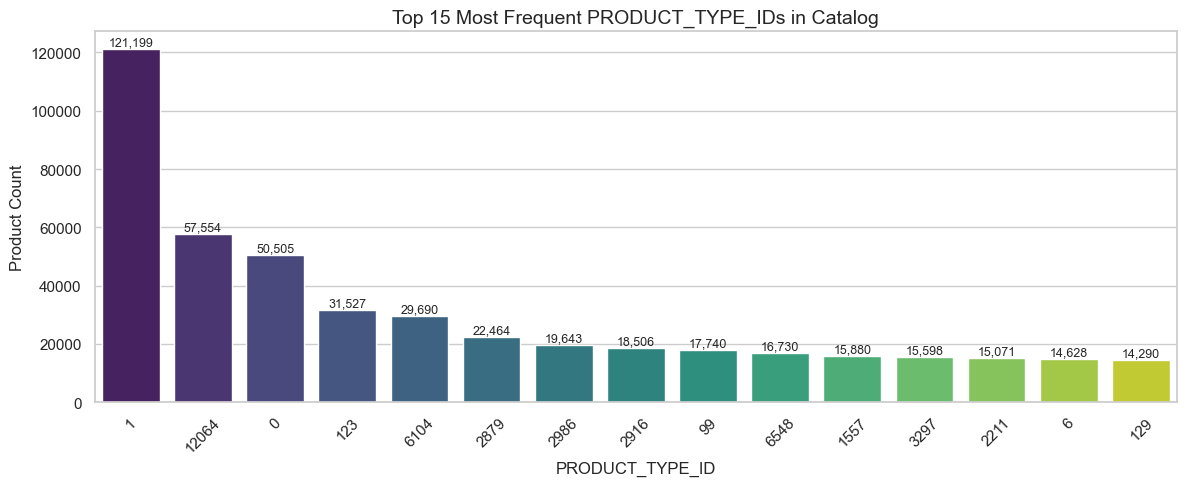

In [11]:
n_unique_types = train_df['PRODUCT_TYPE_ID'].nunique()
print(f"Number of unique PRODUCT_TYPE_IDs: {n_unique_types:,}")

top_types = train_df['PRODUCT_TYPE_ID'].value_counts().head(15)

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=top_types.index.astype(str), y=top_types.values, palette='viridis')
plt.title('Top 15 Most Frequent PRODUCT_TYPE_IDs in Catalog')
plt.xlabel('PRODUCT_TYPE_ID')
plt.ylabel('Product Count')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()


## 7. Target Analysis (PRODUCT_LENGTH)

=== Target Summary Statistics ===
Mean:   4071.8392
Median: 663.0000
Std:    1351684.7500
Min:    1.0000
Max:    1885801400.0000


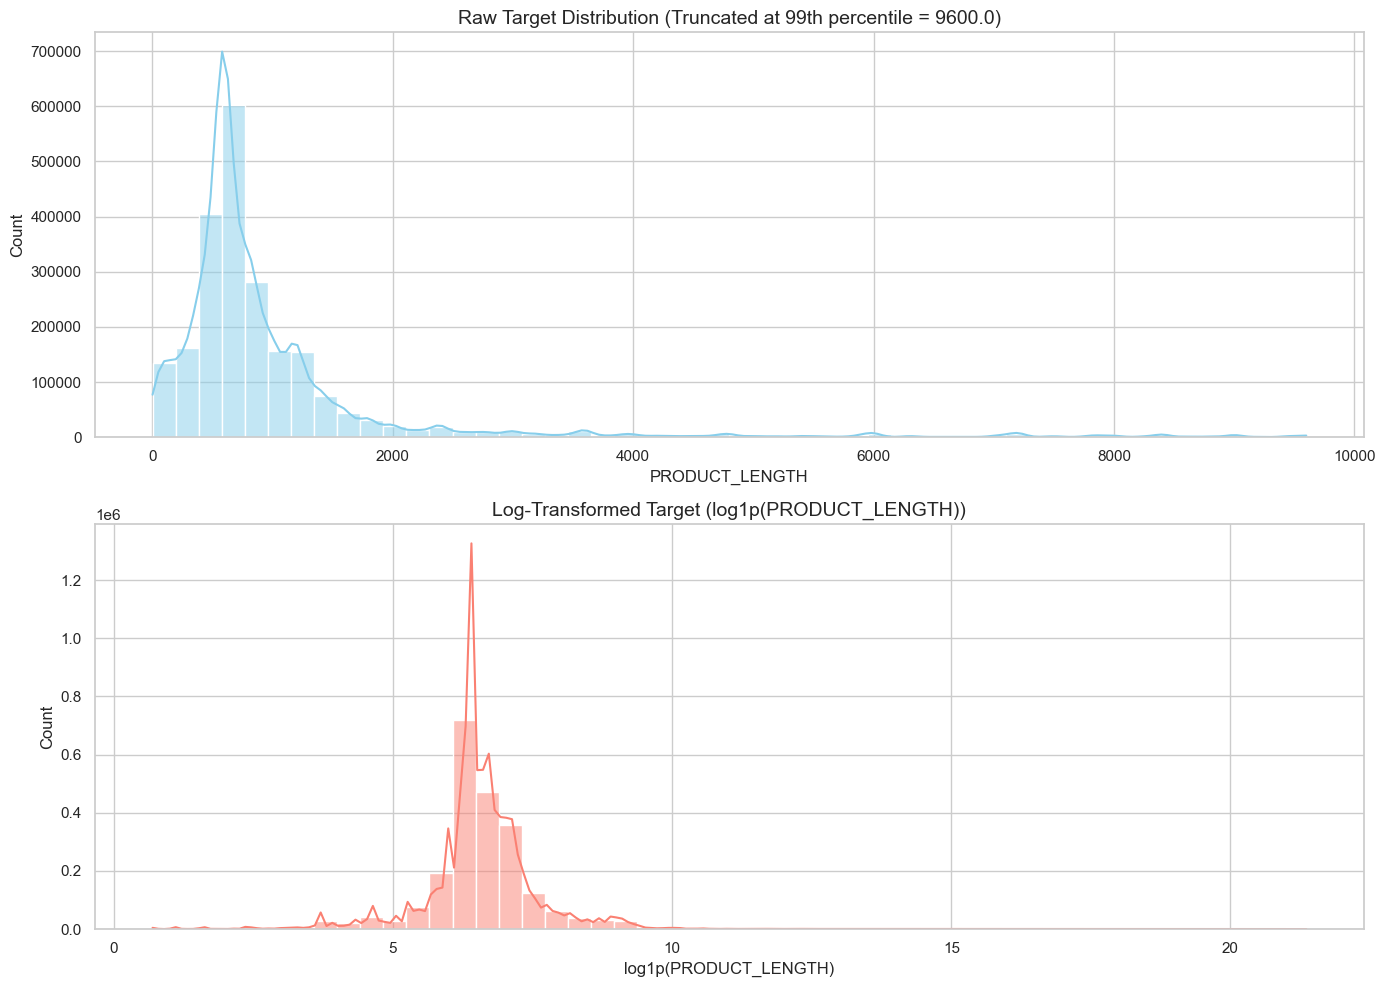

In [21]:
target = train_df['PRODUCT_LENGTH']
print("=== Target Summary Statistics ===")
print(f"Mean:   {target.mean():.4f}")
print(f"Median: {target.median():.4f}")
print(f"Std:    {target.std():.4f}")
print(f"Min:    {target.min():.4f}")
print(f"Max:    {target.max():.4f}")

fig, axes = plt.subplots(2, figsize=(14, 10))

# 1. Raw Distribution (Truncated at 99th percentile for visibility)
q99 = target.quantile(0.99)
sns.histplot(target[target <= q99], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title(f'Raw Target Distribution (Truncated at 99th percentile = {q99:.1f})')
axes[0].set_xlabel('PRODUCT_LENGTH')

# 2. Log-Transformed Distribution
log_target = np.log1p(target)
sns.histplot(log_target, bins=50, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Log-Transformed Target (log1p(PRODUCT_LENGTH))')
axes[1].set_xlabel('log1p(PRODUCT_LENGTH)')


plt.tight_layout()
plt.show()


## 8. Text Length & Composition Visual Exploration

95th Percentile Word Counts:
TITLE: 29 words
DESCRIPTION: 214 words
BULLET_POINTS: 188 words


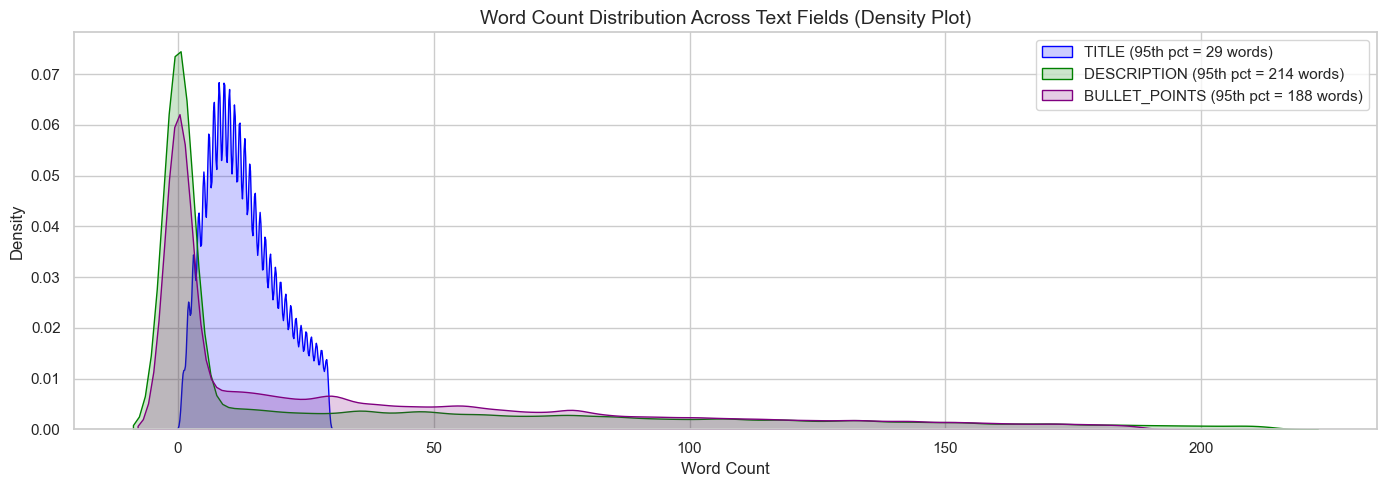

In [13]:
digit_regex = re.compile(r'\d')
punct_regex = re.compile(r'[^\w\s]')

df_text = pd.DataFrame()
for col in text_cols:
    s = train_df[col].fillna('').astype(str)
    df_text[f'{col}_word_cnt'] = s.apply(lambda x: len(x.split()))
    df_text[f'{col}_char_cnt'] = s.str.len()

print("95th Percentile Word Counts:")
for col in text_cols:
    q95 = df_text[f'{col}_word_cnt'].quantile(0.95)
    print(f"{col}: {q95:.0f} words")


# Visualizing Word Count Distributions
plt.figure(figsize=(14, 5))
for col, color in zip(text_cols, ['blue', 'green', 'purple']):
    q95 = df_text[f'{col}_word_cnt'].quantile(0.95)
    sns.kdeplot(df_text[df_text[f'{col}_word_cnt'] <= q95][f'{col}_word_cnt'], 
                label=f'{col} (95th pct = {q95:.0f} words)', color=color, fill=True, alpha=0.2)

plt.title('Word Count Distribution Across Text Fields (Density Plot)')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Numerical & Measurement Exploration

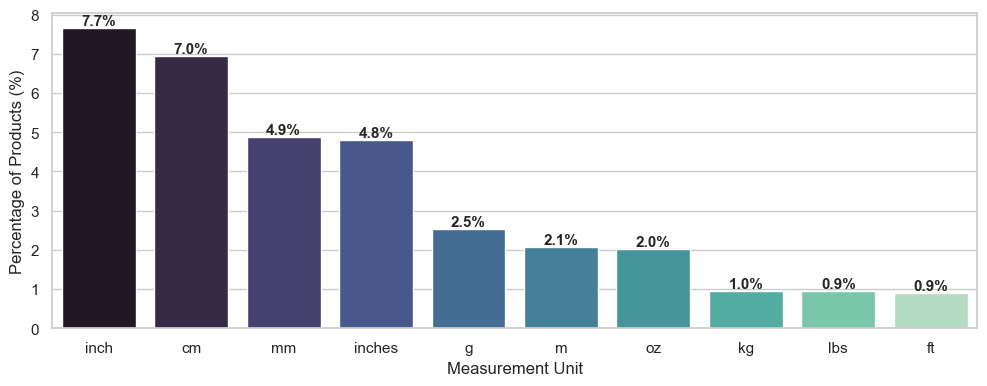

In [14]:
units = ['cm', 'mm', 'inch', 'inches', 'kg', 'g', 'm', 'ft', 'oz', 'lbs']
combined_sample = (train_df['TITLE'].fillna('') + ' ' + 
                   train_df['DESCRIPTION'].fillna('') + ' ' + 
                   train_df['BULLET_POINTS'].fillna('')).str.lower()

unit_counts = {}
for u in units:
    cnt = combined_sample.str.contains(r'\b\d+\s*' + re.escape(u) + r'\b', regex=True).sum()
    pct = (cnt / len(train_df)) * 100
    unit_counts[u] = pct

unit_series = pd.Series(unit_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=unit_series.index, y=unit_series.values, palette='mako')
plt.xlabel('Measurement Unit')
plt.ylabel('Percentage of Products (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Dimension Pattern Exploration

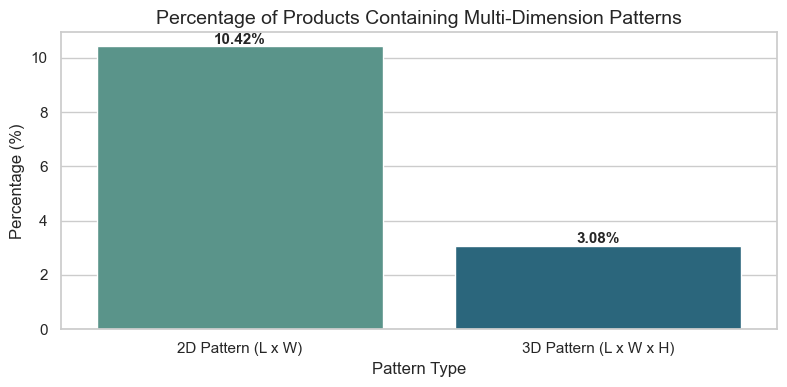

In [15]:
dim_2d_regex = re.compile(r'\b\d+(?:\.\d+)?\s*(?:x|×|\*)\s*\d+(?:\.\d+)?\s*(?:cm|mm|in|inch|inches|m)?\b', re.IGNORECASE)
dim_3d_regex = re.compile(r'\b\d+(?:\.\d+)?\s*(?:x|×|\*)\s*\d+(?:\.\d+)?\s*(?:x|×|\*)\s*\d+(?:\.\d+)?\s*(?:cm|mm|in|inch|inches|m)?\b', re.IGNORECASE)

cnt_2d = combined_sample.apply(lambda x: bool(dim_2d_regex.search(x))).sum()
cnt_3d = combined_sample.apply(lambda x: bool(dim_3d_regex.search(x))).sum()

pattern_df = pd.DataFrame({
    'Pattern Type': ['2D Pattern (L x W)', '3D Pattern (L x W x H)'],
    'Percentage (%)': [(cnt_2d/len(train_df))*100, (cnt_3d/len(train_df))*100]
})

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=pattern_df, x='Pattern Type', y='Percentage (%)', palette='crest')
plt.title('Percentage of Products Containing Multi-Dimension Patterns')
plt.ylabel('Percentage (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Initial Leakage Investigation

In [16]:
train_titles = set(train_df['TITLE'].fillna('').astype(str).str.lower())
test_titles = set(test_df['TITLE'].fillna('').astype(str).str.lower())

overlap = train_titles.intersection(test_titles)
print(f"Unique train titles: {len(train_titles):,}")
print(f"Unique test titles:  {len(test_titles):,}")
print(f"Exact title overlap count: {len(overlap):,} ({(len(overlap)/len(test_titles))*100:.2f}% of test set)")

target_counts = train_df['PRODUCT_LENGTH'].value_counts().head(5)
print("\nTop 5 Most Common Target Values in Train:")
print(target_counts)


Unique train titles: 2,208,723
Unique test titles:  728,544
Exact title overlap count: 18,091 (2.48% of test set)

Top 5 Most Common Target Values in Train:
PRODUCT_LENGTH
600.0000    132095
590.5512     80428
500.0000     62388
393.7008     58178
850.0000     45034
Name: count, dtype: int64


## 12. Train / Validation Split

In [17]:
print("=== Train / Validation Split ===")

train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

print(f"Train split shape:      {train_data.shape}")
print(f"Validation split shape: {val_data.shape}")
print("Split completed reproducibly with test_size=0.2, random_state=42.")


=== Train / Validation Split ===
Train split shape:      (1799758, 6)
Validation split shape: (449940, 6)
Split completed reproducibly with test_size=0.2, random_state=42.


## 13. EDA Conclusions

1. **Log-Transform Necessity**: Target distribution exhibits an extreme right-tail skew. `log1p(PRODUCT_LENGTH)` produces a bell-shaped distribution suitable for Ridge and linear NLP loss optimization.
2. **Text Field Heterogeneity**: `TITLE` is concise and dense in measurement tokens, while `DESCRIPTION` and `BULLET_POINTS` have longer tail distributions. Field-specific weighting will prevent lengthy descriptions from diluting key title signals.
3. **Measurement Signals**: Units (`cm`, `mm`, `inch`, `kg`) and dimension patterns (`L x W x H`) appear in a large fraction of catalog items, demonstrating that character-level n-grams and explicit regex parsers are mandatory.
